# Heart Disease Diagnosis Prediction using Machine Learning

This project predicts the type of heart disease diagnosis using patient medical details.  
The machine learning model was trained using features such as age, gender, chest pain, blood pressure, heart rate, cholesterol level, and other medical conditions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Dataset Overview
The dataset contains 334 patient records and 49 columns.  
It includes both numerical and categorical medical features.

In [2]:
df = pd.read_csv("Heart_disease_details.csv")
df.head()

,Name,Gender,Age,Chest pain,Shortness of breath,Fatigue,Systolic,Diastolic,Heart rate (bpm),Lung sounds,...,Cardiac CT,Obesity,Murmur,Chest x-ray,Previous illnesses,Pulmonary function tests,Spirometry,Diagnosis,Medications,Treatment
0,Jane Doe,Female,55,1,1,1,140,90,100,1,...,Shows a 50% blockage in the left anterior desc...,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, metoprolol, atorvastatin","Angioplasty,Coronary artery bypass surgery"
1,Mark Johnson,Male,57,1,1,1,150,80,110,1,...,Shows a 60% blockage in the right coronary artery,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, ramipril, atorvastatin","Angioplasty,Coronary artery bypass surgery"
2,Emily Davis,Female,60,1,1,1,130,85,95,1,...,Shows a 75% blockage in the left anterior desc...,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, lisinopril, rosuvastatin","Angioplasty,Coronary artery bypass surgery"
3,William Thompson,Male,62,1,1,1,145,90,100,1,...,Shows a 80% blockage in the left circumflex co...,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, metoprolol, atorvastatin","Angioplasty,Coronary artery bypass surgery"
4,Ashley Johnson,Female,58,1,1,1,135,80,105,1,...,Shows a 90% blockage in the right coronary artery,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, simvastatin, lisinopril","Angioplasty,Coronary artery bypass surgery"


In [3]:
df.head()

,Name,Gender,Age,Chest pain,Shortness of breath,Fatigue,Systolic,Diastolic,Heart rate (bpm),Lung sounds,...,Cardiac CT,Obesity,Murmur,Chest x-ray,Previous illnesses,Pulmonary function tests,Spirometry,Diagnosis,Medications,Treatment
0,Jane Doe,Female,55,1,1,1,140,90,100,1,...,Shows a 50% blockage in the left anterior desc...,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, metoprolol, atorvastatin","Angioplasty,Coronary artery bypass surgery"
1,Mark Johnson,Male,57,1,1,1,150,80,110,1,...,Shows a 60% blockage in the right coronary artery,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, ramipril, atorvastatin","Angioplasty,Coronary artery bypass surgery"
2,Emily Davis,Female,60,1,1,1,130,85,95,1,...,Shows a 75% blockage in the left anterior desc...,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, lisinopril, rosuvastatin","Angioplasty,Coronary artery bypass surgery"
3,William Thompson,Male,62,1,1,1,145,90,100,1,...,Shows a 80% blockage in the left circumflex co...,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, metoprolol, atorvastatin","Angioplasty,Coronary artery bypass surgery"
4,Ashley Johnson,Female,58,1,1,1,135,80,105,1,...,Shows a 90% blockage in the right coronary artery,0,1,NaN,NaN,NaN,NaN,Coronary artery disease (CAD),"Aspirin, simvastatin, lisinopril","Angioplasty,Coronary artery bypass surgery"


In [4]:
df.shape

(334, 49)

In [5]:
df.columns

Index(['Name', 'Gender', 'Age', 'Chest pain', 'Shortness of breath', 'Fatigue',
       'Systolic', 'Diastolic', 'Heart rate (bpm)', 'Lung sounds',
       'Cholesterol level (mg/dL)', 'LDL level (mg/dL)', 'HDL level (mg/dL)',
       'Diabetes', 'Atrial fibrillation', 'Mitral valve prolapse',
       'Rheumatic fever', 'Mitral stenosis', 'Aortic stenosis',
       'Tricuspid stenosis', 'Pulmonary stenosis', 'Dilated cardiomyopathy',
       'Hypertrophic cardiomyopathy', 'Restrictive cardiomyopathy',
       'Arrhythmogenic right ventricular cardiomyopathy',
       'Takotsubo cardiomyopathy', 'Drug use', 'Fever', 'Chills', 'Joint pain',
       'Alcoholism', 'Hypertension', 'Fainting', 'Dizziness', 'Smoking',
       'High cholesterol', 'Echocardiogram', 'Blood culture', 'EKG',
       'Cardiac CT', 'Obesity', 'Murmur', 'Chest x-ray', 'Previous illnesses',
       'Pulmonary function tests', 'Spirometry', 'Diagnosis', 'Medications',
       'Treatment'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 49 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Name                                             334 non-null    object
 1   Gender                                           334 non-null    object
 2   Age                                              334 non-null    int64 
 3   Chest pain                                       334 non-null    int64 
 4   Shortness of breath                              334 non-null    int64 
 5   Fatigue                                          334 non-null    int64 
 6   Systolic                                         334 non-null    int64 
 7   Diastolic                                        334 non-null    int64 
 8   Heart rate (bpm)                                 334 non-null    int64 
 9   Lung sounds                                

In [7]:
df.isnull().sum()

,0
Name,0
Gender,0
Age,0
Chest pain,0
Shortness of breath,0
Fatigue,0
Systolic,0
Diastolic,0
Heart rate (bpm),0
Lung sounds,0


In [8]:
df["Diagnosis"].value_counts()

,count
Diagnosis,
Pericarditis with myocarditis,12
Secondary pulmonary hypertension due to scleroderma,12
Secondary pulmonary hypertension due to chronic thromboembolic disease,12
Candidal endocarditis,12
Acute native valve endocarditis,12
Subacute native valve endocarditis,12
Abdominal aortic aneurysm,11
Acute pericarditis,11
Chronic pericarditis,11


In [9]:
df["Diagnosis"].nunique()

31

#Data Preprocessing
In this step, unnecessary text-heavy columns were removed.  
Missing values were handled, and categorical text data was converted into numerical values using Label Encoding.

In [16]:
df_clean = df.drop(["Name", "Cardiac CT", "Chest x-ray", "Previous illnesses",
                    "Pulmonary function tests", "Spirometry",
                    "Medications", "Treatment"], axis=1)

df_clean.head()

,Gender,Age,Chest pain,Shortness of breath,Fatigue,Systolic,Diastolic,Heart rate (bpm),Lung sounds,Cholesterol level (mg/dL),...,Fainting,Dizziness,Smoking,High cholesterol,Echocardiogram,Blood culture,EKG,Obesity,Murmur,Diagnosis
0,Female,55,1,1,1,140,90,100,1,220,...,0,0,1,1,NaN,NaN,Shows evidence of left ventricular hypertrophy,0,1,Coronary artery disease (CAD)
1,Male,57,1,1,1,150,80,110,1,210,...,0,0,1,1,NaN,NaN,Shows evidence of left ventricular hypertrophy,0,1,Coronary artery disease (CAD)
2,Female,60,1,1,1,130,85,95,1,230,...,0,0,1,1,NaN,NaN,Shows evidence of left ventricular hypertrophy,0,1,Coronary artery disease (CAD)
3,Male,62,1,1,1,145,90,100,1,240,...,0,0,1,1,NaN,NaN,Shows evidence of left ventricular hypertrophy,0,1,Coronary artery disease (CAD)
4,Female,58,1,1,1,135,80,105,1,220,...,0,0,1,1,NaN,NaN,Shows evidence of left ventricular hypertrophy,0,1,Coronary artery disease (CAD)


In [17]:
for column in df_clean.columns:
    if df_clean[column].dtype == "object":
        df_clean[column] = df_clean[column].fillna("Unknown")
    else:
        df_clean[column] = df_clean[column].fillna(0)

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in df_clean.columns:
    if df_clean[column].dtype == "object":
        le = LabelEncoder()
        df_clean[column] = le.fit_transform(df_clean[column].astype(str))
        label_encoders[column] = le

df_clean.head()

,Gender,Age,Chest pain,Shortness of breath,Fatigue,Systolic,Diastolic,Heart rate (bpm),Lung sounds,Cholesterol level (mg/dL),...,Fainting,Dizziness,Smoking,High cholesterol,Echocardiogram,Blood culture,EKG,Obesity,Murmur,Diagnosis
0,0,55,1,1,1,140,90,100,1,220,...,0,0,1,1,17,21,24,0,1,8
1,1,57,1,1,1,150,80,110,1,210,...,0,0,1,1,17,21,24,0,1,8
2,0,60,1,1,1,130,85,95,1,230,...,0,0,1,1,17,21,24,0,1,8
3,1,62,1,1,1,145,90,100,1,240,...,0,0,1,1,17,21,24,0,1,8
4,0,58,1,1,1,135,80,105,1,220,...,0,0,1,1,17,21,24,0,1,8


In [19]:
df_clean.isnull().sum()

,0
Gender,0
Age,0
Chest pain,0
Shortness of breath,0
Fatigue,0
Systolic,0
Diastolic,0
Heart rate (bpm),0
Lung sounds,0
Cholesterol level (mg/dL),0


In [20]:
X = df_clean.drop("Diagnosis", axis=1)
y = df_clean["Diagnosis"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model Used
Random Forest Classifier was used because the dataset contains multiple diagnosis categories.  
This is a multi-class classification problem.

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

In [23]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7313432835820896


#Model Evaluation
The model was evaluated using accuracy score, classification report, and confusion matrix.

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       0.75      1.00      0.86         3
           7       0.00      0.00      0.00         1
           8       1.00      0.25      0.40         4
           9       1.00      1.00      1.00         2
          10       1.00      0.80      0.89         5
          11       1.00      0.75      0.86         4
          12       0.60      1.00      0.75         3
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       0.00      0.00      0.00         2
          17       0.67    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0

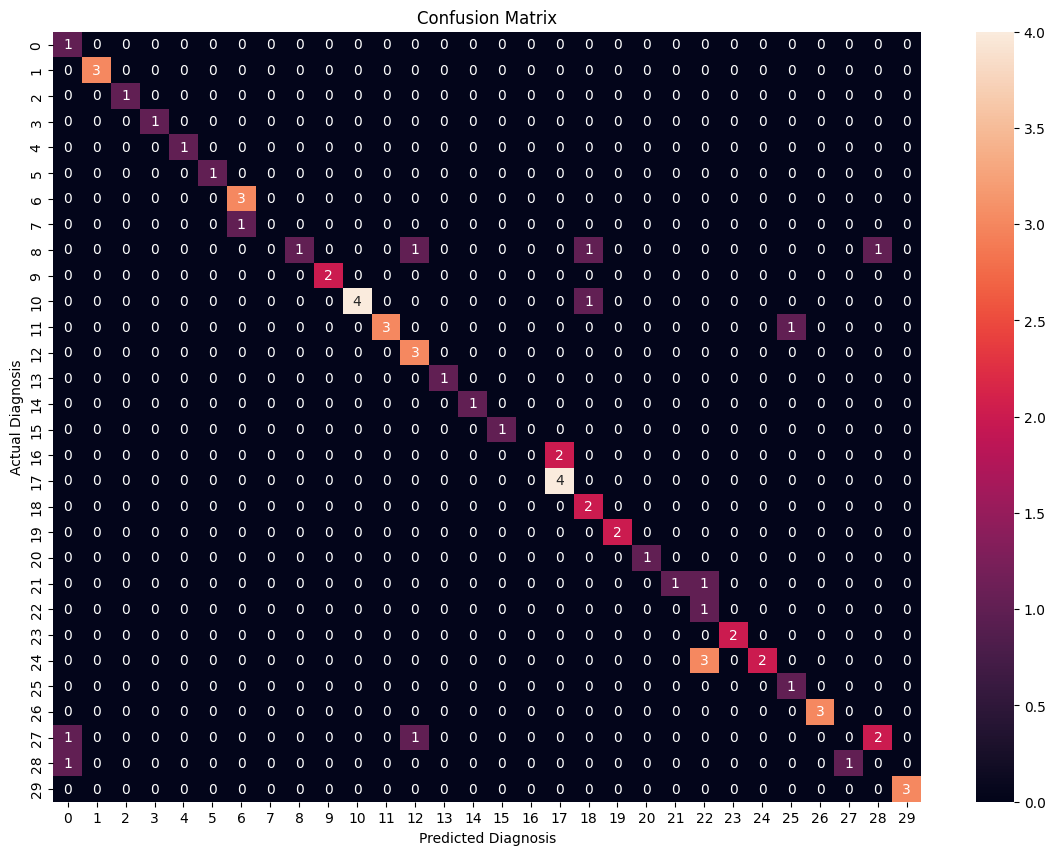

In [28]:
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.show()

In [29]:
sample_patient = X_test.iloc[0]

prediction = model.predict([sample_patient])

print("Predicted Diagnosis Code:", prediction[0])
print("Actual Diagnosis Code:", y_test.iloc[0])

Predicted Diagnosis Code: 14
Actual Diagnosis Code: 14


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [30]:
predicted_diagnosis = label_encoders["Diagnosis"].inverse_transform(prediction)

actual_diagnosis = label_encoders["Diagnosis"].inverse_transform([y_test.iloc[0]])

print("Predicted Diagnosis:", predicted_diagnosis[0])
print("Actual Diagnosis:", actual_diagnosis[0])

Predicted Diagnosis: Mitral stenosis
Actual Diagnosis: Mitral stenosis
